<a href="https://colab.research.google.com/github/mohits2508sse-lab/ML-LAB-EXPERIMENT/blob/main/EXP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Specific Hypothesis:
['?' 'Warm' '?' 'Strong']

Final General Hypotheses:
['?', 'Warm', '?', '?']
['?', '?', '?', 'Strong']


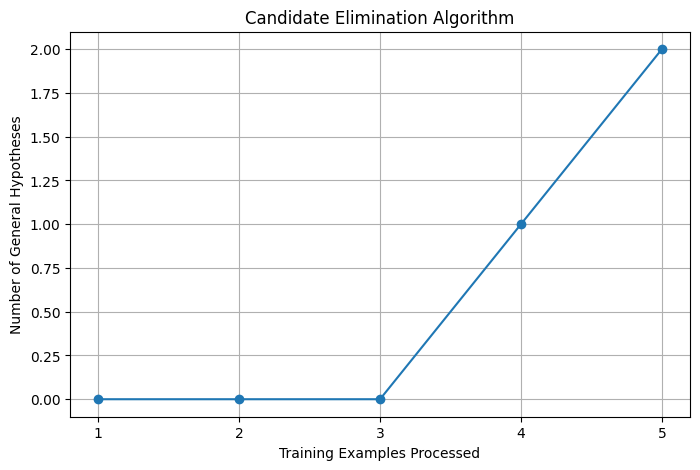

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("training_data.csv")

concepts = data.iloc[:, :-1].values
target = data.iloc[:, -1].values

def candidate_elimination(concepts, target):

    specific_h = concepts[0].copy()

    general_h = [['?' for _ in range(len(specific_h))]
                 for _ in range(len(specific_h))]

    g_history = []

    for i, h in enumerate(concepts):

        if target[i].lower() == "yes":

            for x in range(len(specific_h)):
                if h[x] != specific_h[x]:
                    specific_h[x] = '?'
                    general_h[x][x] = '?'

        elif target[i].lower() == "no":

            for x in range(len(specific_h)):
                if h[x] != specific_h[x]:
                    general_h[x][x] = specific_h[x]
                else:
                    general_h[x][x] = '?'

        current_g = [g for g in general_h if g.count('?') != len(g)]
        g_history.append(len(current_g))

    final_g = [g for g in general_h if g.count('?') != len(g)]

    return specific_h, final_g, g_history

s_final, g_final, g_history = candidate_elimination(concepts, target)

print("Final Specific Hypothesis:")
print(s_final)

print("\nFinal General Hypotheses:")
for g in g_final:
    print(g)

steps = list(range(1, len(g_history) + 1))

plt.figure(figsize=(8,5))
plt.plot(steps, g_history, marker='o')
plt.title("Candidate Elimination Algorithm")
plt.xlabel("Training Examples Processed")
plt.ylabel("Number of General Hypotheses")
plt.xticks(steps)
plt.grid(True)
plt.show()